<a href="https://colab.research.google.com/github/juanjo9926/INTELIGENCIA-ARTIFICIAL-1/blob/main/lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 02 - Regresion Lineal Multiple, Regresion Polinomica y Ecuacion Normal

## Descripcion del trabajo

Este laboratorio implementa tres modelos para predecir el precio promedio ponderado
de frutas y hortalizas en mercados mayoristas de Chile durante el año 2025.

Los modelos implementados son:
- Regresion Lineal Multiple con Descenso por el Gradiente
- Regresion Polinomica con Descenso por el Gradiente
- Calculo de parametros mediante la Ecuacion Normal

Para cada modelo se incluye su respectiva curva de costo y curva de precision,
ademas de la comparacion entre valores reales y predichos.

El dataset utilizado es precio_mayorista_fruta-hortaliza_2025.csv obtenido de ODEPA,
con 113,511 registros y 14 variables, cumpliendo los requisitos m >= 20,000 y n >= 10.

In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

ruta = '/content/gdrive/MyDrive/Colab Notebooks/IA_26/DATASET/precio_mayorista_fruta-hortaliza_2025.csv'

df = pd.read_csv(
    ruta,
    encoding='utf-8-sig',
    sep=',',
    quotechar='"'
)

print("Primeras filas del dataset:")
print(df.head(5))
print(f"\nEl dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas")
print("\nNombres de columnas:")
print(df.columns.tolist())

Mounted at /content/gdrive
Primeras filas del dataset:
        Fecha  ID region                Region  \
0  2025-01-02          5  Región de Valparaíso   
1  2025-01-02          8     Región del Biobío   
2  2025-01-02         16       Región de Ñuble   
3  2025-01-02         16       Región de Ñuble   
4  2025-01-02          4    Región de Coquimbo   

                                Mercado                Subsector Producto  \
0                  Femacal de La Calera  Hortalizas y tubérculos   Acelga   
1            Vega Monumental Concepción  Hortalizas y tubérculos   Acelga   
2  Terminal Hortofrutícola Agro Chillán  Hortalizas y tubérculos   Acelga   
3  Terminal Hortofrutícola Agro Chillán  Hortalizas y tubérculos   Acelga   
4      Terminal La Palmera de La Serena  Hortalizas y tubérculos      Ají   

   Variedad / Tipo  Calidad    Unidad de comercializacion  \
0  Sin especificar  Primera  $/docena de atados (6 kilos)   
1  Sin especificar  Primera          $/atado 0,5 a 1 kilo  

In [ ]:
df.columns = ['Fecha', 'ID_Region', 'Region', 'Mercado', 'Subsector',
              'Producto', 'Variedad', 'Calidad', 'Unidad', 'Origen',
              'Volumen', 'Precio_Min', 'Precio_Max', 'Precio_Prom']

df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Mes'] = df['Fecha'].dt.month
df['Dia'] = df['Fecha'].dt.day

for col in ['Precio_Min', 'Precio_Max', 'Precio_Prom']:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Volumen'] = pd.to_numeric(df['Volumen'], errors='coerce')

from sklearn.preprocessing import LabelEncoder
columnas_categoricas = ['Region', 'Mercado', 'Subsector', 'Producto',
                        'Variedad', 'Calidad', 'Unidad', 'Origen']
le = LabelEncoder()
for col in columnas_categoricas:
    df[col + '_cod'] = le.fit_transform(df[col].astype(str))

df = df.dropna()

print(f"Dataset limpio: {df.shape[0]} filas y {df.shape[1]} columnas")
print(df.dtypes)

Dataset limpio: 113511 filas y 24 columnas
Fecha            datetime64[ns]
ID_Region                 int64
Region                   object
Mercado                  object
Subsector                object
Producto                 object
Variedad                 object
Calidad                  object
Unidad                   object
Origen                   object
Volumen                   int64
Precio_Min              float64
Precio_Max              float64
Precio_Prom             float64
Mes                       int32
Dia                       int32
Region_cod                int64
Mercado_cod               int64
Subsector_cod             int64
Producto_cod              int64
Variedad_cod              int64
Calidad_cod               int64
Unidad_cod                int64
Origen_cod                int64
dtype: object


In [ ]:
features = [
    'ID_Region', 'Mes', 'Dia', 'Volumen',
    'Precio_Min', 'Precio_Max',
    'Region_cod', 'Mercado_cod', 'Subsector_cod', 'Producto_cod',
    'Variedad_cod', 'Calidad_cod', 'Unidad_cod', 'Origen_cod'
]

X = df[features].values
y = df['Precio_Prom'].values

m = y.size
n = X.shape[1]

print(f"Ejemplos de entrenamiento (m): {m}")
print(f"Numero de caracteristicas (n): {n}")
print(f"\n¿Cumple m >= 20000? {m >= 20000}")
print(f"¿Cumple n >= 10?    {n >= 10}")
print(X[:5])

Ejemplos de entrenamiento (m): 113511
Numero de caracteristicas (n): 14

¿Cumple m >= 20000? True
¿Cumple n >= 10?    True
[[5.00e+00 1.00e+00 2.00e+00 1.10e+02 4.00e+03 4.00e+03 5.00e+00 2.00e+00
  1.00e+00 0.00e+00 1.95e+02 4.00e+01 9.70e+01 3.70e+01]
 [8.00e+00 1.00e+00 2.00e+00 3.00e+02 8.00e+02 8.00e+02 7.00e+00 1.10e+01
  1.00e+00 0.00e+00 1.95e+02 4.00e+01 1.00e+00 4.70e+01]
 [1.60e+01 1.00e+00 2.00e+00 2.00e+02 6.00e+02 6.00e+02 6.00e+00 7.00e+00
  1.00e+00 0.00e+00 1.95e+02 4.00e+01 1.00e+00 5.50e+01]
 [1.60e+01 1.00e+00 2.00e+00 6.00e+02 5.00e+02 5.00e+02 6.00e+00 7.00e+00
  1.00e+00 0.00e+00 1.95e+02 4.40e+01 1.00e+00 5.50e+01]
 [4.00e+00 1.00e+00 2.00e+00 4.00e+02 1.50e+04 1.70e+04 2.00e+00 8.00e+00
  1.00e+00 3.00e+00 1.02e+02 4.00e+01 4.60e+01 2.90e+01]]


## Modelo 1: Regresion Lineal Multiple

La regresion lineal multiple busca encontrar los parametros theta que minimizan
el error entre los valores predichos y los valores reales, considerando multiples
variables de entrada simultaneamente.

El proceso sigue estos pasos:
1. Normalizacion de caracteristicas para que todas las variables tengan la misma escala
2. Calculo del costo con la funcion J(theta)
3. Actualizacion iterativa de theta mediante el descenso por el gradiente
4. Evaluacion del modelo con la curva de costo y curva de precision

In [ ]:
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = normalizarCaracteristicas(X)

print('Media calculada:', mu)
print('Desviacion estandar calculada:', sigma)
print(X_norm[:5])

Media calculada: [1.00982460e+01 3.79295399e+00 1.53458431e+01 1.09029723e+03
 2.64297768e+04 2.71131073e+04 2.60056735e+00 6.27666922e+00
 5.66914220e-01 4.59545154e+01 1.40187832e+02 3.52515439e+01
 7.03125512e+01 4.00122896e+01]
Desviacion estandar calculada: [3.82083527e+00 1.93773723e+00 8.57309887e+00 6.31697350e+03
 6.54478632e+04 6.66577079e+04 2.65705953e+00 3.01427771e+00
 4.95502258e-01 2.21285658e+01 6.30224142e+01 1.22435065e+01
 4.64635801e+01 1.40139903e+01]
[[-1.33432761 -1.44134816 -1.55671168 -0.15518464 -0.34271213 -0.34674321
   0.90304061 -1.41880398  0.87403392 -2.07670555  0.86972498  0.38783465
   0.57437349 -0.21494874]
 [-0.54915898 -1.44134816 -1.55671168 -0.12510694 -0.39160601 -0.39474966
   1.65575239  1.56698594  0.87403392 -2.07670555  0.86972498  0.38783465
  -1.49176088  0.49862389]
 [ 1.54462404 -1.44134816 -1.55671168 -0.14093731 -0.39466188 -0.39775006
   1.2793965   0.23996819  0.87403392 -2.07670555  0.86972498  0.38783465
  -1.49176088  1.069482 

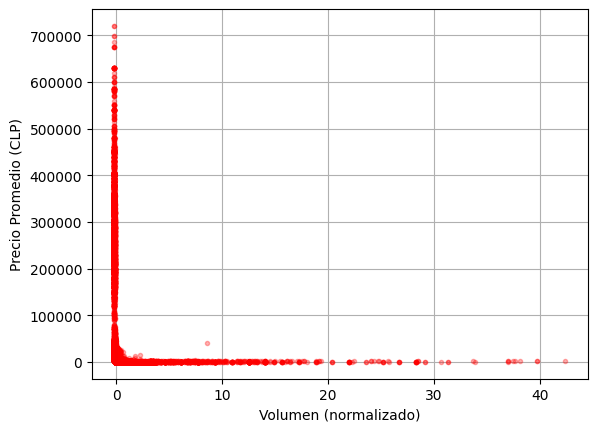

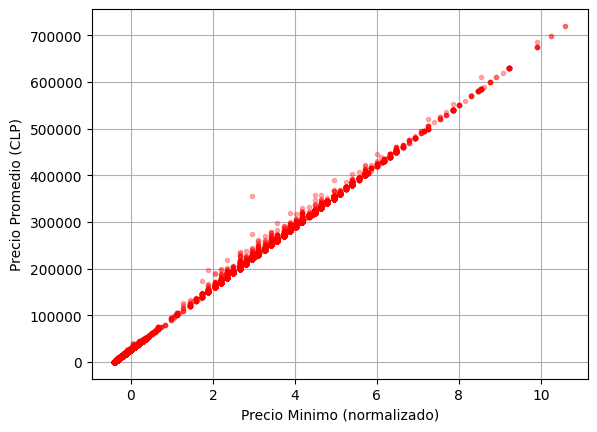

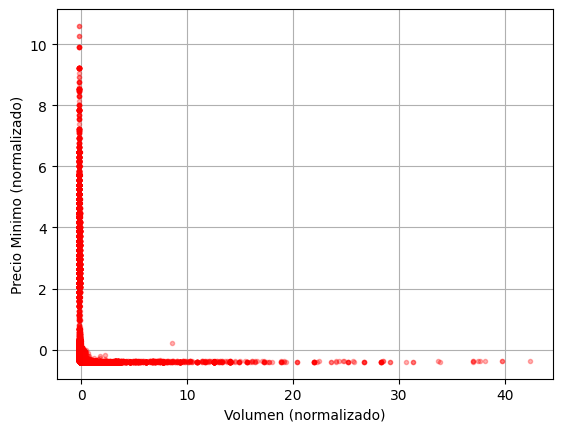

In [ ]:
def graficarDatos(x, y, xlabel, ylabel):
    fig = pyplot.figure()
    pyplot.plot(x, y, 'ro', ms=3, alpha=0.3)
    pyplot.xlabel(xlabel)
    pyplot.ylabel(ylabel)
    pyplot.grid(True)
    pyplot.show()

# Relacion Volumen vs Precio_Prom
graficarDatos(X_norm[:, 3], y, "Volumen (normalizado)", "Precio Promedio (CLP)")

# Relacion Precio_Min vs Precio_Prom
graficarDatos(X_norm[:, 4], y, "Precio Minimo (normalizado)", "Precio Promedio (CLP)")

# Relacion Volumen vs Precio_Min
graficarDatos(X_norm[:, 3], X_norm[:, 4], "Volumen (normalizado)", "Precio Minimo (normalizado)")

In [ ]:
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f"Forma de X_ready: {X_ready.shape}")
print("(Debe ser (113511, 15) — 14 features + 1 columna de unos)")

Forma de X_ready: (113511, 15)
(Debe ser (113511, 15) — 14 features + 1 columna de unos)


In [ ]:
def calcularCosto(X, y, theta):
    m = y.size
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

theta = np.array([0.1] + [0.0] * (X_ready.shape[1] - 1))
JJ = calcularCosto(X_ready, y, theta)
print(f"Con theta inicial se obtiene un costo de: {JJ:.2f}")

Con theta inicial se obtiene un costo de: 2538825186.53


In [ ]:
def calcularDescensoGradiente(X, y, theta, alpha, numero_iteraciones):
    m = y.shape[0]
    theta = theta.copy()
    J_historico = []

    for i in range(numero_iteraciones):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_historico.append(calcularCosto(X, y, theta))

    return theta, J_historico

theta = np.zeros(X_ready.shape[1])
num_ite = 400
alpha = 0.1

theta, J_historico = calcularDescensoGradiente(X_ready, y, theta, alpha, num_ite)
print(f"Theta calculado: {theta}")
print(f"Costo inicial:  {J_historico[0]:,.2f}")
print(f"Costo final:    {J_historico[-1]:,.2f}")

Theta calculado: [ 2.67700543e+04 -2.82382166e+00 -1.46083368e+00 -1.79245475e+00
 -1.76369169e-01  3.30359466e+04  3.30098842e+04 -1.75540955e+00
  2.48767179e-01  5.47128976e-01  3.49829150e-01  3.95245184e-01
 -4.06244520e-01 -1.36091580e+00  2.17658354e-01]
Costo inicial:  1,623,507,900.57
Costo final:    34,430.68


Calculando curva de precision...


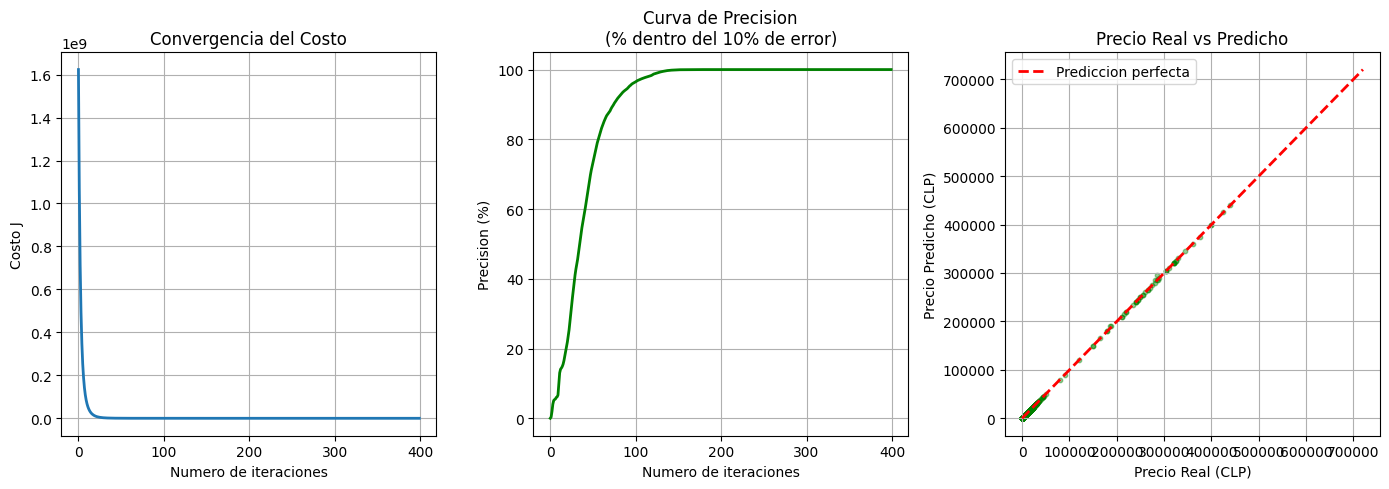

Costo final:     34,430.68
Precision final: 99.99%


In [ ]:
# Calculamos predicciones finales
y_pred = np.dot(X_ready, theta)

# Tolerancia del 10% para precision
tolerancia = 0.10
precision_final = np.mean(np.abs(y_pred - y) / (np.abs(y) + 1e-8) <= tolerancia) * 100

# Curva de precision por iteracion
print("Calculando curva de precision...")
theta_temp = np.zeros(X_ready.shape[1])
precision_history = []

for i in range(num_ite):
    theta_temp = theta_temp - (alpha / m) * (np.dot(X_ready, theta_temp) - y).dot(X_ready)
    y_pred_temp = np.dot(X_ready, theta_temp)
    precision = np.mean(np.abs(y_pred_temp - y) / (np.abs(y) + 1e-8) <= tolerancia) * 100
    precision_history.append(precision)

# Graficas
pyplot.figure(figsize=(14, 5))

# Grafica 1: Curva de costo
pyplot.subplot(1, 3, 1)
pyplot.plot(np.arange(len(J_historico)), J_historico, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo')
pyplot.grid(True)

# Grafica 2: Curva de precision
pyplot.subplot(1, 3, 2)
pyplot.plot(np.arange(len(precision_history)), precision_history, lw=2, color='green')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Precision (%)')
pyplot.title('Curva de Precision\n(% dentro del 10% de error)')
pyplot.grid(True)

# Grafica 3: Real vs Predicho
pyplot.subplot(1, 3, 3)
indices = np.random.choice(len(y), 1000, replace=False)
pyplot.scatter(y[indices], y_pred[indices], alpha=0.4, color='green', s=10)
pyplot.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Prediccion perfecta')
pyplot.xlabel('Precio Real (CLP)')
pyplot.ylabel('Precio Predicho (CLP)')
pyplot.title('Precio Real vs Predicho')
pyplot.legend()
pyplot.grid(True)

pyplot.tight_layout()
pyplot.show()

print(f"Costo final:     {J_historico[-1]:,.2f}")
print(f"Precision final: {precision_final:.2f}%")

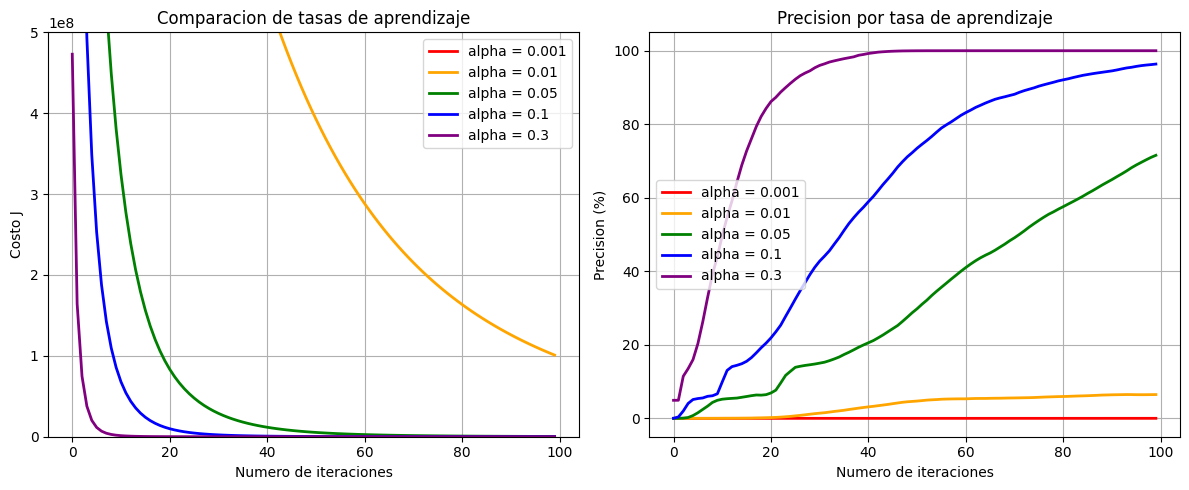

In [ ]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.3]
colores = ['red', 'orange', 'green', 'blue', 'purple']

pyplot.figure(figsize=(12, 5))

pyplot.subplot(1, 2, 1)
for a, color in zip(alphas, colores):
    theta_temp = np.zeros(X_ready.shape[1])
    _, J_temp = calcularDescensoGradiente(X_ready, y, theta_temp, a, 100)
    pyplot.plot(np.arange(len(J_temp)), J_temp, lw=2,
                label=f'alpha = {a}', color=color)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Comparacion de tasas de aprendizaje')
pyplot.legend()
pyplot.grid(True)
pyplot.ylim(0, 500000000)

pyplot.subplot(1, 2, 2)
for a, color in zip(alphas, colores):
    theta_temp = np.zeros(X_ready.shape[1])
    prec_temp = []
    for i in range(100):
        theta_temp = theta_temp - (a / m) * (np.dot(X_ready, theta_temp) - y).dot(X_ready)
        y_p = np.dot(X_ready, theta_temp)
        prec_temp.append(np.mean(np.abs(y_p - y) / (np.abs(y) + 1e-8) <= tolerancia) * 100)
    pyplot.plot(np.arange(100), prec_temp, lw=2,
                label=f'alpha = {a}', color=color)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Precision (%)')
pyplot.title('Precision por tasa de aprendizaje')
pyplot.legend()
pyplot.grid(True)

pyplot.tight_layout()
pyplot.show()

In [ ]:
nuevo_ejemplo = np.array([
    13, 3, 15, 200, 8000, 12000, 5, 8, 0, 10, 3, 0, 2, 6
], dtype=float)

nuevo_normalizado = (nuevo_ejemplo - mu) / sigma
nuevo_con_uno = np.concatenate([[1], nuevo_normalizado])
precio_predicho = np.dot(nuevo_con_uno, theta)

print(f"Region: Metropolitana, Mes: Marzo, Volumen: 200")
print(f"Precio predicho con Descenso Gradiente: ${precio_predicho:,.2f} CLP")

Region: Metropolitana, Mes: Marzo, Volumen: 200
Precio predicho con Descenso Gradiente: $9,980.76 CLP


## Ecuacion Normal

La ecuacion normal es un metodo analitico que calcula los parametros theta optimos
de forma directa, sin necesidad de iteraciones. Utiliza la formula:

theta = (X^T * X)^(-1) * X^T * y

A diferencia del descenso por el gradiente, no requiere normalizar los datos
ni definir una tasa de aprendizaje. Sin embargo, con datasets grandes puede
ser computacionalmente costoso.

In [ ]:
X_normal = df[features].values
X_normal = np.concatenate([np.ones((X_normal.shape[0], 1)), X_normal], axis=1)

def calcularThetaEcuacionNormal(X, y):
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

print("Calculando ecuacion normal (puede tardar)...")
theta_normal = calcularThetaEcuacionNormal(X_normal, y)

ejemplo_normal = np.concatenate([[1], nuevo_ejemplo])
precio_normal = np.dot(ejemplo_normal, theta_normal)

print(f"Precio predicho con Ecuacion Normal:    ${precio_normal:,.2f} CLP")
print(f"Precio predicho con Descenso Gradiente: ${precio_predicho:,.2f} CLP")
print(f"\n(Si los valores son parecidos, ambos metodos funcionaron bien)")

Calculando ecuacion normal (puede tardar)...
Precio predicho con Ecuacion Normal:    $9,974.31 CLP
Precio predicho con Descenso Gradiente: $9,980.76 CLP

(Si los valores son parecidos, ambos metodos funcionaron bien)


## Modelo 2: Regresion Polinomica

La regresion polinomica extiende la regresion lineal agregando terminos al cuadrado
de las variables de entrada. Esto permite capturar relaciones no lineales entre
las caracteristicas y la variable objetivo.

En este caso se agregan los terminos X^2 a las 14 variables existentes,
obteniendo 28 caracteristicas en total. El proceso de normalizacion, descenso
por el gradiente y evaluacion es el mismo que en la regresion lineal multiple.

In [ ]:
# Recargamos X original sin normalizar
X_poly_base = df[features].values
y_poly = df['Precio_Prom'].values
m_poly = y_poly.size

# Agregamos los terminos al cuadrado (X y X^2)
X_poly = np.concatenate([X_poly_base, X_poly_base * X_poly_base], axis=1)

print(f"Forma de X con terminos polinomicos: {X_poly.shape}")
print("(Debe ser (113511, 28) — 14 features + 14 features al cuadrado)")
print(X_poly[:3])

Forma de X con terminos polinomicos: (113511, 28)
(Debe ser (113511, 28) — 14 features + 14 features al cuadrado)
[[5.0000e+00 1.0000e+00 2.0000e+00 1.1000e+02 4.0000e+03 4.0000e+03
  5.0000e+00 2.0000e+00 1.0000e+00 0.0000e+00 1.9500e+02 4.0000e+01
  9.7000e+01 3.7000e+01 2.5000e+01 1.0000e+00 4.0000e+00 1.2100e+04
  1.6000e+07 1.6000e+07 2.5000e+01 4.0000e+00 1.0000e+00 0.0000e+00
  3.8025e+04 1.6000e+03 9.4090e+03 1.3690e+03]
 [8.0000e+00 1.0000e+00 2.0000e+00 3.0000e+02 8.0000e+02 8.0000e+02
  7.0000e+00 1.1000e+01 1.0000e+00 0.0000e+00 1.9500e+02 4.0000e+01
  1.0000e+00 4.7000e+01 6.4000e+01 1.0000e+00 4.0000e+00 9.0000e+04
  6.4000e+05 6.4000e+05 4.9000e+01 1.2100e+02 1.0000e+00 0.0000e+00
  3.8025e+04 1.6000e+03 1.0000e+00 2.2090e+03]
 [1.6000e+01 1.0000e+00 2.0000e+00 2.0000e+02 6.0000e+02 6.0000e+02
  6.0000e+00 7.0000e+00 1.0000e+00 0.0000e+00 1.9500e+02 4.0000e+01
  1.0000e+00 5.5000e+01 2.5600e+02 1.0000e+00 4.0000e+00 4.0000e+04
  3.6000e+05 3.6000e+05 3.6000e+01 4.9000e+0

### Normalizacion de caracteristicas

Al igual que en la regresion lineal multiple, es necesario normalizar las
caracteristicas antes de aplicar el descenso por el gradiente. Esto es especialmente
importante en la regresion polinomica porque los terminos al cuadrado generan
valores mucho mas grandes que los originales, lo que sin normalizacion causaria
que el modelo no converja correctamente.

In [ ]:
X_poly_norm, mu_poly, sigma_poly = normalizarCaracteristicas(X_poly)

print('Media calculada (primeras 5):', mu_poly[:5])
print('Desviacion estandar calculada (primeras 5):', sigma_poly[:5])
print(X_poly_norm[:3])

Media calculada (primeras 5): [1.00982460e+01 3.79295399e+00 1.53458431e+01 1.09029723e+03
 2.64297768e+04]
Desviacion estandar calculada (primeras 5): [3.82083527e+00 1.93773723e+00 8.57309887e+00 6.31697350e+03
 6.54478632e+04]
[[-1.33432761 -1.44134816 -1.55671168 -0.15518464 -0.34271213 -0.34674321
   0.90304061 -1.41880398  0.87403392 -2.07670555  0.86972498  0.38783465
   0.57437349 -0.21494874 -1.24145    -1.11685577 -1.09067536 -0.04755084
  -0.21128206 -0.21334572  0.59266187 -1.24086229  0.87403392 -1.36821049
   0.90339693  0.34107147  0.32077977 -0.44691318]
 [-0.54915898 -1.44134816 -1.55671168 -0.12510694 -0.39160601 -0.39474966
   1.65575239  1.56698594  0.87403392 -2.07670555  0.86972498  0.38783465
  -1.49176088  0.49862389 -0.71273124 -1.11685577 -1.09067536 -0.04746067
  -0.21193557 -0.21398051  1.8652554   2.02291699  0.87403392 -1.36821049
   0.90339693  0.34107147 -0.98777553  0.42943782]
 [ 1.54462404 -1.44134816 -1.55671168 -0.14093731 -0.39466188 -0.39775006
  

In [ ]:
X_poly_ready = np.concatenate([np.ones((m_poly, 1)), X_poly_norm], axis=1)

print(f"Forma final de X polinomico: {X_poly_ready.shape}")
print("(Debe ser (113511, 29) — 28 features + 1 columna de unos)")

Forma final de X polinomico: (113511, 29)
(Debe ser (113511, 29) — 28 features + 1 columna de unos)


In [ ]:
theta_poly = np.array([0.1] + [0.0] * (X_poly_ready.shape[1] - 1))
JJ_poly = calcularCosto(X_poly_ready, y_poly, theta_poly)
print(f"Con theta inicial se obtiene un costo de: {JJ_poly:.2f}")

Con theta inicial se obtiene un costo de: 2538825186.53


### Entrenamiento con Descenso por el Gradiente

Se aplica el mismo algoritmo de descenso por el gradiente utilizado en la regresion
lineal multiple. El modelo ajusta iterativamente los 29 parametros theta (1 sesgo +
28 caracteristicas) para minimizar el error de costo sobre los 113,511 ejemplos
de entrenamiento.

In [ ]:
theta_poly = np.zeros(X_poly_ready.shape[1])
num_ite_poly = 400
alpha_poly = 0.1

theta_poly, J_historico_poly = calcularDescensoGradiente(
    X_poly_ready, y_poly, theta_poly, alpha_poly, num_ite_poly
)

print(f"Theta calculado (primeros 5): {theta_poly[:5]}")
print(f"Costo inicial:  {J_historico_poly[0]:,.2f}")
print(f"Costo final:    {J_historico_poly[-1]:,.2f}")

Theta calculado (primeros 5): [ 2.67700543e+04 -1.13372761e+02  1.27630853e+02 -1.28185687e+01
 -6.15574723e+01]
Costo inicial:  1,048,790,893.89
Costo final:    75,679.05


### Curva de Costo y Curva de Precision

La curva de costo muestra como disminuye el error en cada iteracion del entrenamiento.
La curva de precision muestra el porcentaje de predicciones que se encuentran dentro
del 10% de error respecto al valor real, permitiendo evaluar que tan bien generaliza
el modelo en cada iteracion.

Calculando curva de precision polinomica...


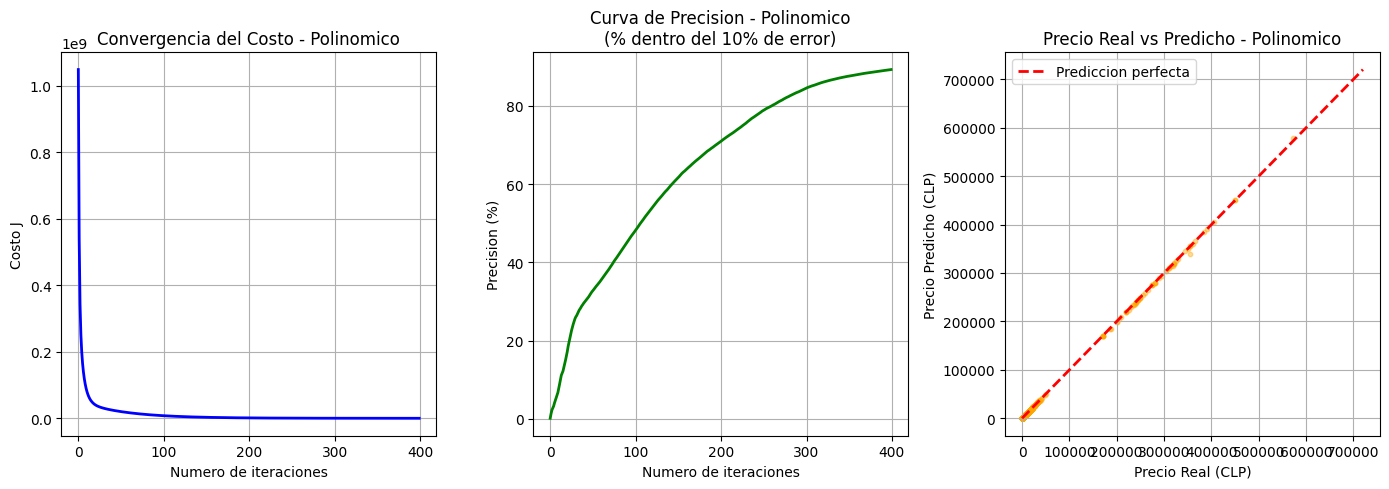

Costo final:     75,679.05
Precision final: 89.30%


In [ ]:
# Predicciones finales
y_pred_poly = np.dot(X_poly_ready, theta_poly)

# Tolerancia del 10%
tolerancia_poly = 0.10
precision_final_poly = np.mean(
    np.abs(y_pred_poly - y_poly) / (np.abs(y_poly) + 1e-8) <= tolerancia_poly
) * 100

# Curva de precision por iteracion
print("Calculando curva de precision polinomica...")
theta_temp_poly = np.zeros(X_poly_ready.shape[1])
precision_history_poly = []

for i in range(num_ite_poly):
    theta_temp_poly = theta_temp_poly - (alpha_poly / m_poly) * (
        np.dot(X_poly_ready, theta_temp_poly) - y_poly
    ).dot(X_poly_ready)
    y_pred_temp = np.dot(X_poly_ready, theta_temp_poly)
    precision = np.mean(
        np.abs(y_pred_temp - y_poly) / (np.abs(y_poly) + 1e-8) <= tolerancia_poly
    ) * 100
    precision_history_poly.append(precision)

# Graficas
pyplot.figure(figsize=(14, 5))

# Grafica 1: Curva de costo
pyplot.subplot(1, 3, 1)
pyplot.plot(np.arange(len(J_historico_poly)), J_historico_poly, lw=2, color='blue')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo - Polinomico')
pyplot.grid(True)

# Grafica 2: Curva de precision
pyplot.subplot(1, 3, 2)
pyplot.plot(np.arange(len(precision_history_poly)), precision_history_poly, lw=2, color='green')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Precision (%)')
pyplot.title('Curva de Precision - Polinomico\n(% dentro del 10% de error)')
pyplot.grid(True)

# Grafica 3: Real vs Predicho
pyplot.subplot(1, 3, 3)
indices = np.random.choice(len(y_poly), 1000, replace=False)
pyplot.scatter(y_poly[indices], y_pred_poly[indices], alpha=0.4, color='orange', s=10)
pyplot.plot([y_poly.min(), y_poly.max()], [y_poly.min(), y_poly.max()],
            'r--', lw=2, label='Prediccion perfecta')
pyplot.xlabel('Precio Real (CLP)')
pyplot.ylabel('Precio Predicho (CLP)')
pyplot.title('Precio Real vs Predicho - Polinomico')
pyplot.legend()
pyplot.grid(True)

pyplot.tight_layout()
pyplot.show()

print(f"Costo final:     {J_historico_poly[-1]:,.2f}")
print(f"Precision final: {precision_final_poly:.2f}%")

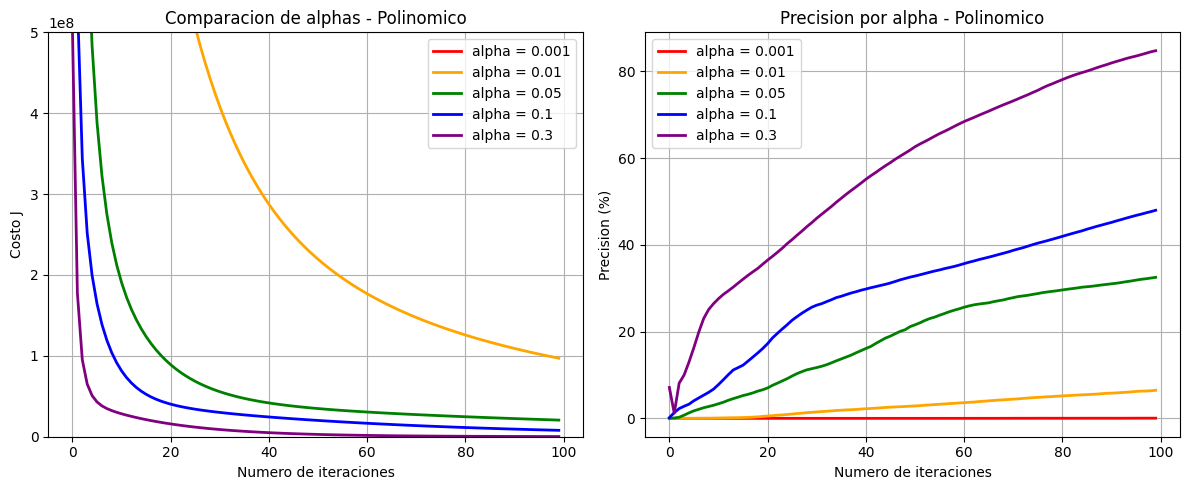

In [ ]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.3]
colores = ['red', 'orange', 'green', 'blue', 'purple']

pyplot.figure(figsize=(12, 5))

pyplot.subplot(1, 2, 1)
for a, color in zip(alphas, colores):
    theta_temp = np.zeros(X_poly_ready.shape[1])
    _, J_temp = calcularDescensoGradiente(X_poly_ready, y_poly, theta_temp, a, 100)
    pyplot.plot(np.arange(len(J_temp)), J_temp, lw=2,
                label=f'alpha = {a}', color=color)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Comparacion de alphas - Polinomico')
pyplot.legend()
pyplot.grid(True)
pyplot.ylim(0, 500000000)

pyplot.subplot(1, 2, 2)
for a, color in zip(alphas, colores):
    theta_temp = np.zeros(X_poly_ready.shape[1])
    prec_temp = []
    for i in range(100):
        theta_temp = theta_temp - (a / m_poly) * (
            np.dot(X_poly_ready, theta_temp) - y_poly
        ).dot(X_poly_ready)
        y_p = np.dot(X_poly_ready, theta_temp)
        prec_temp.append(np.mean(
            np.abs(y_p - y_poly) / (np.abs(y_poly) + 1e-8) <= tolerancia_poly
        ) * 100)
    pyplot.plot(np.arange(100), prec_temp, lw=2,
                label=f'alpha = {a}', color=color)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Precision (%)')
pyplot.title('Precision por alpha - Polinomico')
pyplot.legend()
pyplot.grid(True)

pyplot.tight_layout()
pyplot.show()

### Prediccion con el Modelo Polinomico

Para realizar una prediccion con el modelo entrenado se deben seguir los mismos
pasos que en la regresion lineal multiple: construir el vector de entrada, agregar
los terminos al cuadrado, normalizar con los mismos valores mu y sigma del
entrenamiento, agregar el termino de sesgo y multiplicar por theta.

In [ ]:
nuevo_ejemplo_poly = np.array([
    13, 3, 15, 200, 8000, 12000, 5, 8, 0, 10, 3, 0, 2, 6
], dtype=float)

# Agregamos terminos al cuadrado
nuevo_poly = np.concatenate([nuevo_ejemplo_poly, nuevo_ejemplo_poly ** 2])

# Normalizamos con los valores del entrenamiento polinomico
nuevo_poly_norm = (nuevo_poly - mu_poly) / sigma_poly
nuevo_poly_con_uno = np.concatenate([[1], nuevo_poly_norm])

precio_predicho_poly = np.dot(nuevo_poly_con_uno, theta_poly)

print(f"Region: Metropolitana, Mes: Marzo, Volumen: 200")
print(f"Precio predicho con Regresion Polinomica: ${precio_predicho_poly:,.2f} CLP")

Region: Metropolitana, Mes: Marzo, Volumen: 200
Precio predicho con Regresion Polinomica: $10,195.76 CLP


### Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

θ = (X^T * X)^(-1) * X^T * y

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se
obtendra una solucion exacta con un solo calculo: no hay "bucles de convergencia"
como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas.
Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna
de unos a la matriz X para tener el termino de interseccion (θ0).

Calculando ecuacion normal polinomica (puede tardar)...
Precio predicho con Ecuacion Normal Polinomica:    $-16,675.24 CLP
Precio predicho con Descenso Gradiente Polinomico: $10,195.76 CLP

(Si los valores son parecidos, ambos metodos funcionaron bien)


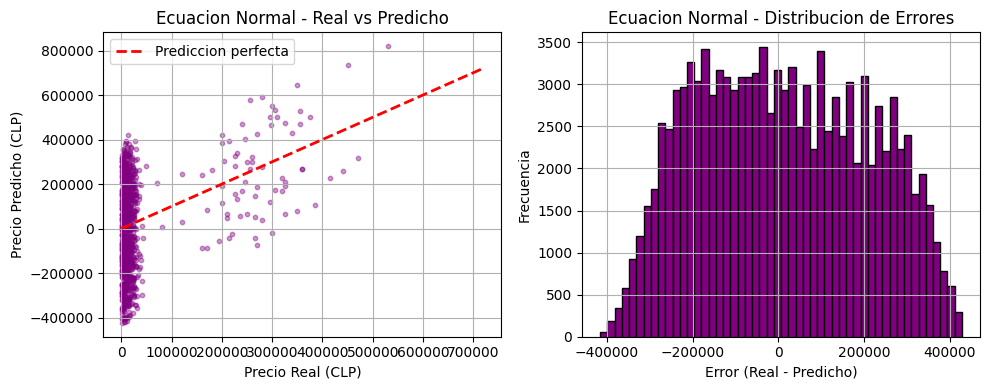

Precision Ecuacion Normal:          0.82%
Precision Descenso Gradiente:       89.30%


In [ ]:
# Recargamos X sin normalizar
X_poly_normal = np.concatenate([X_poly_base, X_poly_base * X_poly_base], axis=1)
X_poly_normal = np.concatenate([np.ones((m_poly, 1)), X_poly_normal], axis=1)

def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

print("Calculando ecuacion normal polinomica (puede tardar)...")
theta_normal_poly = normalEqn(X_poly_normal, y_poly)

# Prediccion con ejemplo nuevo
ejemplo_normal_poly = np.concatenate([[1], nuevo_poly])
precio_normal_poly = np.dot(ejemplo_normal_poly, theta_normal_poly)

print(f"Precio predicho con Ecuacion Normal Polinomica:    ${precio_normal_poly:,.2f} CLP")
print(f"Precio predicho con Descenso Gradiente Polinomico: ${precio_predicho_poly:,.2f} CLP")
print(f"\n(Si los valores son parecidos, ambos metodos funcionaron bien)")

# Precision final de la ecuacion normal
y_pred_normal_poly = np.dot(X_poly_normal, theta_normal_poly)
precision_normal_poly = np.mean(
    np.abs(y_pred_normal_poly - y_poly) / (np.abs(y_poly) + 1e-8) <= 0.10
) * 100

# Graficas
pyplot.figure(figsize=(10, 4))

# Grafica 1: Real vs Predicho
pyplot.subplot(1, 2, 1)
indices = np.random.choice(len(y_poly), 1000, replace=False)
pyplot.scatter(y_poly[indices], y_pred_normal_poly[indices], alpha=0.4, color='purple', s=10)
pyplot.plot([y_poly.min(), y_poly.max()], [y_poly.min(), y_poly.max()],
            'r--', lw=2, label='Prediccion perfecta')
pyplot.xlabel('Precio Real (CLP)')
pyplot.ylabel('Precio Predicho (CLP)')
pyplot.title('Ecuacion Normal - Real vs Predicho')
pyplot.legend()
pyplot.grid(True)

# Grafica 2: Distribucion de errores
pyplot.subplot(1, 2, 2)
errores_normal = y_poly - y_pred_normal_poly
pyplot.hist(errores_normal, bins=50, color='purple', edgecolor='black')
pyplot.xlabel('Error (Real - Predicho)')
pyplot.ylabel('Frecuencia')
pyplot.title('Ecuacion Normal - Distribucion de Errores')
pyplot.grid(True)

pyplot.tight_layout()
pyplot.show()

print(f"Precision Ecuacion Normal:          {precision_normal_poly:.2f}%")
print(f"Precision Descenso Gradiente:       {precision_final_poly:.2f}%")

In [ ]:
print(f"Regresion Lineal Multiple:")
print(f"  Costo final:     {J_historico[-1]:,.2f}")
print(f"  Precision final: {precision_final:.2f}%")

print(f"\nRegresion Polinomica:")
print(f"  Costo final:     {J_historico_poly[-1]:,.2f}")
print(f"  Precision final: {precision_final_poly:.2f}%")

Regresion Lineal Multiple:
  Costo final:     34,430.68
  Precision final: 99.99%

Regresion Polinomica:
  Costo final:     75,679.05
  Precision final: 89.30%


## Comparacion de Modelos

| Modelo | Costo Final | Precision Final |
|---|---|---|
| Regresion Lineal Multiple | 34,430.68 | 99.99% |
| Regresion Polinomica | 75,679.05 | 89.30% |
| Ecuacion Normal Polinomica | - | 0.82% |

En este caso la regresion lineal multiple obtuvo un mejor desempeño que la regresion
polinomica, con un costo final menor y una precision significativamente mas alta.
Esto indica que las relaciones entre las variables y el precio promedio ponderado
son predominantemente lineales en este dataset.

La ecuacion normal polinomica obtuvo una precision muy baja (0.82%) en comparacion
con el descenso por el gradiente (89.30%), lo que sugiere que sin normalizacion
los terminos al cuadrado generan valores muy grandes que afectan negativamente
el calculo directo de theta.